<a href="https://colab.research.google.com/github/pichain23/ai-on-aks/blob/main/Copy_of_Let's_Build_Baku_ML_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From F1 results to a Baku prediction 🏁

Our question: **Who does the model rank highest for the Azerbaijan Grand Prix?**

**Race results → useful clues → learn patterns → test on unseen races → predict Baku**

These are the 6 steps:
1. Our data
2. Understanding our data
3. Feature Engineering
4. Training the model
5. Testing the model
6. Interpreting our results

This is an educational **pre-qualifying** model. It uses no qualifying, grid, weather or live laps.

In [ ]:
# @title Install the notebook tools
%pip -q install "fastf1>=3.6,<4" "scikit-learn>=1.6,<2" "xgboost>=3.0,<4" matplotlib joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.7/424.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 2.2 MB/s eta 0:00:00


In [ ]:
# @title Prepare tools and helpers (expand only if are a curious :) )
from pathlib import Path
from collections import defaultdict, deque
from datetime import datetime, timezone
import json, time, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1, sklearn, joblib, xgboost
from fastf1.ergast import Ergast
from xgboost import XGBClassifier
from IPython.display import display

TARGET_YEAR = 2026
START_YEAR = 2018
TEST_YEAR = TARGET_YEAR - 1
assert TARGET_YEAR >= 2022, "Choose 2022 or later to leave enough training history."
CACHE = Path('baku_cache'); CACHE.mkdir(exist_ok=True)
OUT = Path('baku_outputs'); OUT.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE))
api = Ergast(limit=100)
print('FastF1', fastf1.__version__, '| XGBoost', xgboost.__version__)

def retry(fn):
    for attempt in range(4):
        try:
            return fn()
        except Exception:
            if attempt == 3:
                raise
            time.sleep(2 ** (attempt + 1))

def season_results(year):
    path = CACHE / f'results_{year}_{datetime.now(timezone.utc):%Y%m%d}.csv'
    if path.exists():
        return pd.read_csv(path, parse_dates=['raceDate'])
    page = retry(lambda: api.get_race_results(season=year))
    chunks = []
    received = 0
    while True:
        for (_, meta), result in zip(page.description.iterrows(), page.content):
            frame = pd.DataFrame(result).copy()
            for name in ['season', 'round', 'raceDate', 'circuitId', 'raceName']:
                frame[name] = meta[name]
            chunks.append(frame)
            received += len(frame)
        if received >= page.total_results:
            break
        try:
            time.sleep(0.4)
            page = retry(page.get_next_result_page)
        except ValueError as exc:
            if 'No more data' in str(exc):
                break
            raise
    if not chunks:
        return pd.DataFrame()
    frame = pd.concat(chunks, ignore_index=True).drop_duplicates(['season','round','driverId'])
    frame.to_csv(path, index=False)
    return frame


FEATURES = ['driver_finish_5','driver_points_5','driver_win_rate_5',
            'driver_podium_rate_5','team_points_5','team_win_rate_5',
            'circuit_finish_3','circuit_win_rate_3','driver_history_count']
drivers = defaultdict(lambda: deque(maxlen=5))
teams = defaultdict(lambda: deque(maxlen=5))
circuits = defaultdict(lambda: deque(maxlen=3))

def avg(records, column):
    return float(np.mean([r[column] for r in records])) if records else np.nan

def features(driver, team, circuit):
    d, t, c = drivers[driver], teams[team], circuits[(driver,circuit)]
    return dict(zip(FEATURES, [avg(d,'finish'), avg(d,'points'), avg(d,'win'),
        avg(d,'podium'), avg(t,'points'), avg(t,'win'), avg(c,'finish'),
        avg(c,'win'), len(d)]))


def build_training_table(history):
    drivers.clear(); teams.clear(); circuits.clear()
    rows = []
    for (season, rnd), race in history.groupby(['season','round'], sort=True):
        for _, r in race.iterrows():
            rows.append({**features(r.driverId, r.constructorId, r.circuitId),
                'season': int(season), 'round': int(rnd),
                'race_id': f'{season}-{rnd}', 'raceName': r.raceName,
                'circuitId': r.circuitId, 'driverId': r.driverId,
                'driver': f'{r.givenName} {r.familyName}', 'won': int(r.position == 1)})
        for _, r in race.iterrows():
            record = dict(finish=float(r.position), points=float(r.points),
                          win=int(r.position == 1), podium=int(r.position <= 3))
            drivers[r.driverId].append(record)
            circuits[(r.driverId,r.circuitId)].append(record)
        for team, team_race in race.groupby('constructorId'):
            teams[team].append(dict(points=float(team_race.points.sum()),
                                   win=int(team_race.position.eq(1).any())))
    data = pd.DataFrame(rows)
    data = data.loc[data.season > START_YEAR].copy()
    return data

def new_model():
    return XGBClassifier(n_estimators=120, max_depth=3,
        learning_rate=0.06, reg_lambda=5.0, min_child_weight=5,
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', n_jobs=2, random_state=42)


def predict_field(field, fitted_model=None):
    fitted_model = model if fitted_model is None else fitted_model
    result = field[['driverId','driver','team']].copy()
    scores = fitted_model.predict_proba(field[FEATURES])[:,1]
    result['win_score'] = scores / scores.sum()
    return result.sort_values('win_score', ascending=False).reset_index(drop=True)



FastF1 3.8.3 | XGBoost 3.4.1


## 1 · Where does the data come from?
FastF1 is the Python tool we use to request F1 results that feeds our machine learning model!


In [ ]:
TARGET_YEAR = 2026
TEST_YEAR = TARGET_YEAR - 1
schedule = retry(lambda: api.get_race_schedule(season=TARGET_YEAR))
baku = schedule.loc[schedule.circuitId.eq('baku')]
assert len(baku) == 1, 'Choose a season with one Baku race.'
target = baku.iloc[0]
target_date = pd.Timestamp(target.raceDate).tz_localize(None).normalize()
print(f"Our target: {target.raceName}, {target_date.date()}")

Our target: Azerbaijan Grand Prix, 2026-09-26


In [ ]:
# Ask for each season, then combine the results into one table.
frames = [season_results(year) for year in range(START_YEAR, TARGET_YEAR + 1)]
raw = pd.concat(frames, ignore_index=True)
print(f"Downloaded {len(raw):,} driver results.")

Downloaded 3,766 driver results.


## 2 · What does the data look like?

In [ ]:
# @title Keep eligible races and check the data
raw['raceDate'] = pd.to_datetime(raw['raceDate']).dt.tz_localize(None)
history = raw.loc[raw['raceDate'] < target_date].copy()
history['position'] = pd.to_numeric(history['position'], errors='raise')
history['points'] = pd.to_numeric(history['points'], errors='raise')
history = history.sort_values(['raceDate','season','round','position'])
assert not history.duplicated(['season','round','driverId']).any()
race_checks = history.groupby(['season','round']).agg(
    entrants=('driverId','size'), winners=('position', lambda s: s.eq(1).sum()))
assert race_checks['entrants'].ge(18).all(), 'Incomplete race data detected.'
assert race_checks['winners'].eq(1).all(), 'Each race must have exactly one winner.'
assert history['season'].max() == TARGET_YEAR, 'No current-season results. Check data availability.'


In [ ]:
# Find the most recent completed race.
latest_race = history[
    history.raceDate == history.raceDate.max()
]

# Show its top five finishers and the points they earned.
preview = latest_race.sort_values('position')[
    ['raceDate', 'raceName', 'givenName', 'familyName',
     'constructorName', 'position', 'points']
].head(5)

display(preview.reset_index(drop=True))

# Summarize the full dataset used by the notebook.
race_count = history.groupby(['season', 'round']).ngroups
print(f"{race_count} completed races in our dataset")
print(f"Data through {history.raceDate.max().date()}")

,raceDate,raceName,givenName,familyName,constructorName,position,points
0,2026-09-13,Spanish Grand Prix,Andrea Kimi,Antonelli,Mercedes,1,25.0
1,2026-09-13,Spanish Grand Prix,Max,Verstappen,Red Bull,2,18.0
2,2026-09-13,Spanish Grand Prix,Lando,Norris,McLaren,3,15.0
3,2026-09-13,Spanish Grand Prix,Charles,Leclerc,Ferrari,4,12.0
4,2026-09-13,Spanish Grand Prix,George,Russell,Mercedes,5,10.0


187 completed races in our dataset
Data through 2026-09-13


## 3 · What is a feature?
A feature is a clue we give the model. Instead of giving it every old race, we summarize recent performance via features.

### One simple example
If a driver's last five finishes were **2, 1, 4, 3, 5**, their recent average finish would be **3.0**. Lower is better. These are illustrative numbers so you can nderstand better, not like a statement that's definitive about the driver.

### Our nine clues, in three groups

| Group | Feature | Meaning |
|---|---|---|
| Driver form | `driver_finish_5` | Average finish over the driver's last 5 starts |
| Driver form | `driver_points_5` | Average points over those starts |
| Driver form | `driver_win_rate_5` | Fraction of those starts won |
| Driver form | `driver_podium_rate_5` | Fraction finished in the top 3 |
| Team form | `team_points_5` | Average combined team points over its last 5 races |
| Team form | `team_win_rate_5` | Fraction of those races won by either team driver |
| Circuit history | `circuit_finish_3` | Average finish over the driver's last 3 starts at this circuit |
| Circuit history | `circuit_win_rate_3` | Fraction of those circuit starts won |
| Available history | `driver_history_count` | Available prior driver starts, capped at 5 |

In training, “this circuit” means the circuit of that historical race. For our forecast, it means **Baku**. If fewer starts exist, we use those available, missing averages stay missing.


### Note: Usually there are more features when I share the model the day before the race because I take into account qualifying results, other things like clean air race pace. This is another piece or pieces of data that are one of the most important in creating your ML models. If we have more pieces of data that we know are good "Clues" the model will perform better.

In [ ]:
# Build the full training dataset.
data = build_training_table(history)

selected_drivers = [
    'max_verstappen', 'norris', 'leclerc',
    'hamilton', 'russell'
]

# Find each selected driver's most recent example.
selected = data[data['driverId'].isin(selected_drivers)]
latest = (
    selected.sort_values(['season', 'round'])
    .groupby('driverId', sort=False)
    .tail(1)
)

print("1. Recent driver form")
display(latest[
    ['driver', 'raceName', 'driver_finish_5',
     'driver_points_5', 'driver_win_rate_5',
     'driver_podium_rate_5']
].round(2).reset_index(drop=True))

print("2. How one driver's features changed across races")
driver_history = selected[
    selected['driverId'] == 'max_verstappen'
].sort_values(['season', 'round']).tail(5)

display(driver_history[
    ['season', 'raceName', 'driver',
     'driver_finish_5', 'team_points_5', 'won']
].round(2).reset_index(drop=True))

1. Recent driver form


,driver,raceName,driver_finish_5,driver_points_5,driver_win_rate_5,driver_podium_rate_5
0,Max Verstappen,Spanish Grand Prix,10.0,9.6,0.0,0.6
1,Lando Norris,Spanish Grand Prix,3.4,16.0,0.4,0.4
2,Charles Leclerc,Spanish Grand Prix,6.8,13.0,0.2,0.4
3,George Russell,Spanish Grand Prix,7.2,11.4,0.0,0.6
4,Lewis Hamilton,Spanish Grand Prix,4.4,11.4,0.0,0.2


2. How one driver's features changed across races


,season,raceName,driver,driver_finish_5,team_points_5,won
0,2026,Belgian Grand Prix,Max Verstappen,10.2,19.2,0
1,2026,Hungarian Grand Prix,Max Verstappen,10.2,18.8,0
2,2026,Dutch Grand Prix,Max Verstappen,6.2,21.0,0
3,2026,Italian Grand Prix,Max Verstappen,9.8,18.2,0
4,2026,Spanish Grand Prix,Max Verstappen,10.0,16.0,0


## 4 · Where do we train the model?
Training means learning patterns from examples where we already know the answer.

First we divide the races in time. For the 2026 forecast, the teaching model learns from **2019–2024** and is tested on **2025**.
We keep whole races together!!
We do not randomly mix drivers from the same race between train and test.

In [ ]:
train = data.loc[data.season < TEST_YEAR]
test = data.loc[data.season == TEST_YEAR].copy()
assert train.race_id.nunique() >= 30 and test.race_id.nunique() >= 10
assert set(train.race_id).isdisjoint(test.race_id)
print(f"TRAIN: {train.season.min()}–{train.season.max()} | {train.race_id.nunique()} races")
print(f"TEST:  {TEST_YEAR} | {test.race_id.nunique()} races")

TRAIN: 2019–2024 | 128 races
TEST:  2025 | 24 races


**Inputs → XGBoost → learned patterns**

XGBoost combines many small decision trees. Each new tree helps correct errors made by the earlier trees.

X_train contains the nine clues. y_train contains the winner labels. .fit() is the training step.

In [ ]:
X_train = train[FEATURES]  # The clues/features
y_train = train['won']    # The known answers

evaluation_model = new_model()
evaluation_model.fit(X_train, y_train)
print("Training complete. Now let's test on races it did not train on.")

Training complete. Now let's test on races it did not train on.


## 5 · How do we test it?
We give the model the test-season features/clues without the answers, pick its highest-scoring driver in each race, then check who actually won.


In [ ]:
test['raw_score'] = evaluation_model.predict_proba(test[FEATURES])[:, 1]
test['win_score'] = test.raw_score / test.groupby('race_id').raw_score.transform('sum')
picks = test.loc[test.groupby('race_id').win_score.idxmax()]
print(f"Model picked {picks.won.sum()} winners correctly out of {len(picks)} races.")

Model picked 8 winners correctly out of 24 races.


In [ ]:
baseline_rows = test.assign(baseline=test.driver_finish_5.fillna(99))
baseline = baseline_rows.loc[baseline_rows.groupby('race_id').baseline.idxmin()]
report = pd.DataFrame({
    'Method': ['XGBoost', 'Best recent finish'],
    'Correct winners': [int(picks.won.sum()), int(baseline.won.sum())],
    'Races': [len(picks), len(baseline)],
    'Accuracy': [f'{picks.won.mean():.1%}', f'{baseline.won.mean():.1%}']})
display(report)
metrics = {'test_year': TEST_YEAR, 'test_races': len(picks),
           'winner_accuracy': float(picks.won.mean()),
           'recent_form_baseline_accuracy': float(baseline.won.mean())}

,Method,Correct winners,Races,Accuracy
0,XGBoost,8,24,33.3%
1,Best recent finish,7,24,29.2%


## 6 · What does the model predict for Baku?
The test told us how this approach performed. Now we train a final copy using all eligible completed races before Baku.

This final fit includes the former test season. Its training score is **not** a new test result; the honest result remains the held-out test above.

In [ ]:
model = new_model()
model.fit(data[FEATURES], data['won'])
print("Final Baku model trained on all eligible pre-race examples.")

Final Baku model trained on all eligible pre-race examples.


In [ ]:
# @title Prepare the provisional field and its nine clues
latest = history.loc[history.raceDate.eq(history.raceDate.max())].copy()
entries = latest[['driverId','constructorId','constructorName','givenName','familyName']].copy()
entries['driver'] = entries.givenName + ' ' + entries.familyName
entries = entries.rename(columns={'constructorName':'team'})[['driverId','constructorId','driver','team']]
entry_source = 'Most recent completed race; confirm substitutions'
if Path('baku_entries.csv').exists():
    entries = pd.read_csv('baku_entries.csv')
    assert {'driverId','constructorId','driver','team'} <= set(entries.columns)
    entry_source = 'User-supplied entry list'
assert entries.driverId.is_unique and len(entries) >= 18
assert entries[['driverId','constructorId','driver','team']].notna().all().all()
inputs = pd.DataFrame([features(r.driverId,r.constructorId,'baku') for r in entries.itertuples()])
inputs = pd.concat([entries.reset_index(drop=True), inputs], axis=1)



In [ ]:
predictions = predict_field(inputs)
assert np.isclose(predictions.win_score.sum(), 1)
print(f"MODEL TOP PICK: {predictions.iloc[0].driver}")
display(predictions[['driver', 'team', 'win_score']].head(5)
        .assign(win_score=lambda table: table.win_score.map('{:.1%}'.format)) )

MODEL TOP PICK: Andrea Kimi Antonelli


,driver,team,win_score
0,Andrea Kimi Antonelli,Mercedes,53.6%
1,Max Verstappen,Red Bull,13.2%
2,Lando Norris,McLaren,10.9%
3,George Russell,Mercedes,7.8%
4,Charles Leclerc,Ferrari,5.5%


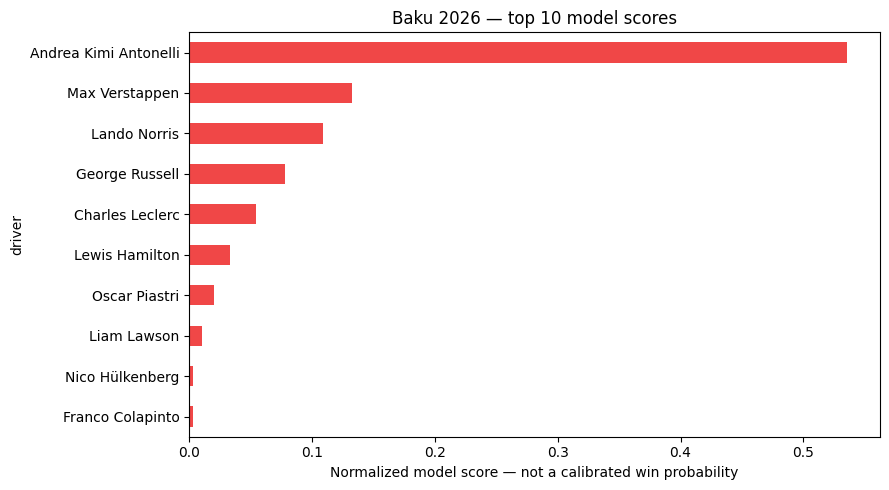

In [ ]:
ax = predictions.head(10).sort_values('win_score').plot.barh(
    x='driver', y='win_score', legend=False, color='#F04747', figsize=(9, 5))
ax.set_title(f'Baku {TARGET_YEAR} — top 10 model scores')
ax.set_xlabel('Normalized model score — not a calibrated win probability')
plt.tight_layout()
plt.show()

These scores help rank the field. A 50% model score does not mean we have proved a 50% chance of winning though

The model cannot see qualifying, weather, tyre strategy, accidents, other data that is super valueable and arguable more important until race weekend begins!

In [ ]:
# @title Save the model and its results
payload = {
    'race': 'Azerbaijan Grand Prix', 'circuit': 'baku', 'year': TARGET_YEAR,
    'model_type': 'XGBClassifier', 'xgboost_version': xgboost.__version__,
    'race_date': target_date.date().isoformat(),
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'data_through': history.raceDate.max().date().isoformat(),
    'entry_source': entry_source, 'mode': 'pre_qualifying',
    'score_label': 'Normalized model score; not a calibrated win probability',
    'model_pick': predictions.iloc[0].driver,
    'evaluation': metrics, 'predictions': predictions.to_dict(orient='records')}
(OUT/'baku_predictions.json').write_text(json.dumps(payload, indent=2, allow_nan=False))
inputs.to_json(OUT/'baku_inputs.json', orient='records', indent=2)
predictions.to_csv(OUT/'baku_predictions.csv', index=False)
joblib.dump({'model':model, 'features':FEATURES, 'metadata':payload}, OUT/'baku_model.joblib')
model.save_model(OUT/'baku_model.json')
(OUT/'baku_model_metadata.json').write_text(json.dumps(
    {'features': FEATURES, 'metadata': payload}, indent=2, allow_nan=False))
(OUT/'requirements.txt').write_text(
    f'xgboost=={xgboost.__version__}\nscikit-learn=={sklearn.__version__}\nfastf1=={fastf1.__version__}\n'
    f'pandas=={pd.__version__}\nnumpy=={np.__version__}\njoblib=={joblib.__version__}\n')
with zipfile.ZipFile('baku_lovable_bundle.zip','w',zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir(): z.write(p, p.name)
with zipfile.ZipFile('baku_cache.zip','w',zipfile.ZIP_DEFLATED) as z:
    for p in CACHE.rglob('*'):
        if p.is_file(): z.write(p, str(p))
print('Created baku_lovable_bundle.zip and baku_cache.zip. Download from the Colab Files sidebar.')
# Optional one-click download in Colab:
# from google.colab import files
# files.download('baku_lovable_bundle.zip')


Created baku_lovable_bundle.zip and baku_cache.zip. Download from the Colab Files sidebar.


In [ ]:
# @title Export the dashboard kit and Python reference checks
reference_cases = []
for value in [None, 1.0, 5.0, 12.0, 20.0]:
    field = inputs.copy()
    if value is not None:
        field.loc[0, 'driver_finish_5'] = value
    raw_scores = model.predict_proba(field[FEATURES])[:, 1]
    reference_cases.append({
        'name': 'baseline' if value is None else f'finish-{value}',
        'inputs': json.loads(field.to_json(orient='records')),
        'raw_scores': raw_scores.tolist(),
        'win_scores': (raw_scores / raw_scores.sum()).tolist()})
field = inputs.copy()
field.loc[0, FEATURES] = np.nan
raw_scores = model.predict_proba(field[FEATURES])[:, 1]
reference_cases.append({'name': 'missing-inputs',
    'inputs': json.loads(field.to_json(orient='records')),
    'raw_scores': raw_scores.tolist(),
    'win_scores': (raw_scores / raw_scores.sum()).tolist()})
model.save_model(OUT / 'baku_model.json')
dashboard_kit = {'model': json.loads((OUT / 'baku_model.json').read_text()),
    'metadata': payload, 'inputs': json.loads(inputs.to_json(orient='records')),
    'verification': reference_cases}
kit_path = OUT / 'Baku_XGBoost_Dashboard_Data.json'
kit_path.write_text(json.dumps(dashboard_kit, separators=(',', ':'), allow_nan=False))
with zipfile.ZipFile('baku_lovable_bundle.zip', 'w', zipfile.ZIP_DEFLATED) as bundle:
    for exported_file in OUT.iterdir():
        if exported_file.is_file():
            bundle.write(exported_file, exported_file.name)
print('READY FOR LOVABLE:', kit_path)
print('The API server will evaluate this trained model; training stays in Colab.')

READY FOR LOVABLE: baku_outputs/Baku_XGBoost_Dashboard_Data.json
The API server will evaluate this trained model; training stays in Colab.
